In [1]:
print("hello")

hello


In [4]:
import pandas as pd
df = pd.read_csv("data/ds_salaries.csv")
df.head()

,Unnamed: 0,work_year,experience_level,employment_type,job_title,salary,salary_currency,salary_in_usd,employee_residence,remote_ratio,company_location,company_size
0,0,2020,MI,FT,Data Scientist,70000,EUR,79833,DE,0,DE,L
1,1,2020,SE,FT,Machine Learning Scientist,260000,USD,260000,JP,0,JP,S
2,2,2020,SE,FT,Big Data Engineer,85000,GBP,109024,GB,50,GB,M
3,3,2020,MI,FT,Product Data Analyst,20000,USD,20000,HN,0,HN,S
4,4,2020,SE,FT,Machine Learning Engineer,150000,USD,150000,US,50,US,L


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 607 entries, 0 to 606
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype
---  ------              --------------  -----
 0   Unnamed: 0          607 non-null    int64
 1   work_year           607 non-null    int64
 2   experience_level    607 non-null    str  
 3   employment_type     607 non-null    str  
 4   job_title           607 non-null    str  
 5   salary              607 non-null    int64
 6   salary_currency     607 non-null    str  
 7   salary_in_usd       607 non-null    int64
 8   employee_residence  607 non-null    str  
 9   remote_ratio        607 non-null    int64
 10  company_location    607 non-null    str  
 11  company_size        607 non-null    str  
dtypes: int64(5), str(7)
memory usage: 57.0 KB


In [6]:
df.describe()

,Unnamed: 0,work_year,salary,salary_in_usd,remote_ratio
count,607.000000,607.000000,6.070000e+02,607.000000,607.00000
mean,303.000000,2021.405272,3.240001e+05,112297.869852,70.92257
std,175.370085,0.692133,1.544357e+06,70957.259411,40.70913
min,0.000000,2020.000000,4.000000e+03,2859.000000,0.00000
25%,151.500000,2021.000000,7.000000e+04,62726.000000,50.00000
50%,303.000000,2022.000000,1.150000e+05,101570.000000,100.00000
75%,454.500000,2022.000000,1.650000e+05,150000.000000,100.00000
max,606.000000,2022.000000,3.040000e+07,600000.000000,100.00000


In [7]:
df.isnull().sum()

Unnamed: 0            0
work_year             0
experience_level      0
employment_type       0
job_title             0
salary                0
salary_currency       0
salary_in_usd         0
employee_residence    0
remote_ratio          0
company_location      0
company_size          0
dtype: int64

In [8]:
df.drop("Unnamed: 0", axis=1)

,work_year,experience_level,employment_type,job_title,salary,salary_currency,salary_in_usd,employee_residence,remote_ratio,company_location,company_size
0,2020,MI,FT,Data Scientist,70000,EUR,79833,DE,0,DE,L
1,2020,SE,FT,Machine Learning Scientist,260000,USD,260000,JP,0,JP,S
2,2020,SE,FT,Big Data Engineer,85000,GBP,109024,GB,50,GB,M
3,2020,MI,FT,Product Data Analyst,20000,USD,20000,HN,0,HN,S
4,2020,SE,FT,Machine Learning Engineer,150000,USD,150000,US,50,US,L
...,...,...,...,...,...,...,...,...,...,...,...
602,2022,SE,FT,Data Engineer,154000,USD,154000,US,100,US,M
603,2022,SE,FT,Data Engineer,126000,USD,126000,US,100,US,M
604,2022,SE,FT,Data Analyst,129000,USD,129000,US,0,US,M
605,2022,SE,FT,Data Analyst,150000,USD,150000,US,100,US,M


In [9]:
df.groupby("job_title")["salary_in_usd"].mean().sort_values(ascending=False).head(10)

job_title
Data Analytics Lead         405000.000000
Principal Data Engineer     328333.333333
Financial Data Analyst      275000.000000
Principal Data Scientist    215242.428571
Director of Data Science    195074.000000
Data Architect              177873.909091
Applied Data Scientist      175655.000000
Analytics Engineer          175000.000000
Data Specialist             165000.000000
Head of Data                160162.600000
Name: salary_in_usd, dtype: float64

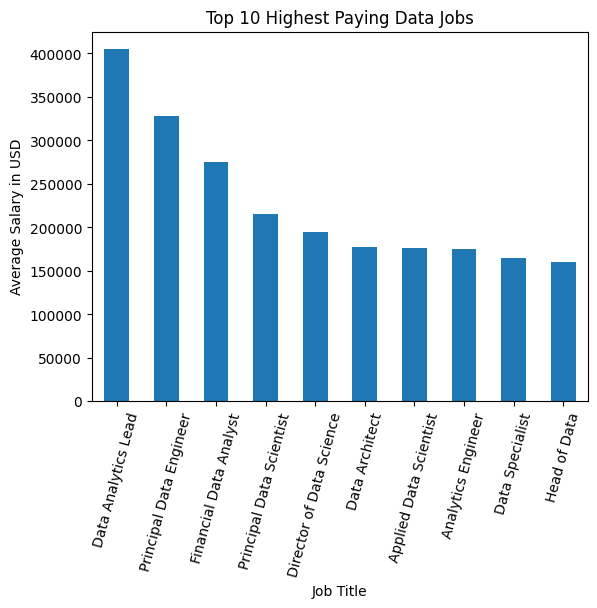

In [10]:
import matplotlib.pyplot as plt

top_jobs = df.groupby("job_title")["salary_in_usd"].mean().sort_values(ascending=False).head(10)

top_jobs.plot(kind="bar")

plt.title("Top 10 Highest Paying Data Jobs")
plt.xlabel("Job Title")
plt.ylabel("Average Salary in USD")

plt.xticks(rotation=75)

plt.savefig("images/top_jobs_salary.png", bbox_inches="tight")

plt.show()

In [11]:
experience_salary = df.groupby("experience_level")["salary_in_usd"].mean()

experience_salary

experience_level
EN     61643.318182
EX    199392.038462
MI     87996.056338
SE    138617.292857
Name: salary_in_usd, dtype: float64

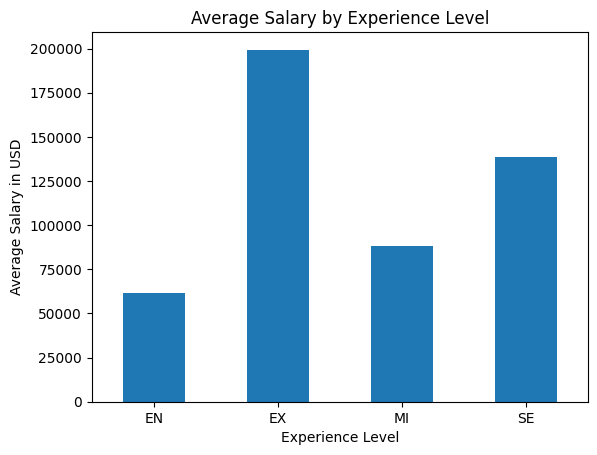

In [11]:
experience_salary = df.groupby("experience_level")["salary_in_usd"].mean()

experience_salary.plot(kind="bar")

plt.title("Average Salary by Experience Level")
plt.xlabel("Experience Level")
plt.ylabel("Average Salary in USD")

plt.xticks(rotation=0)

plt.savefig("images/experience_salary.png", bbox_inches="tight")

plt.show()

In [13]:
remote_salary = df.groupby("remote_ratio")["salary_in_usd"].mean()

remote_salary

remote_ratio
0      106354.622047
50      80823.030303
100    122457.454068
Name: salary_in_usd, dtype: float64

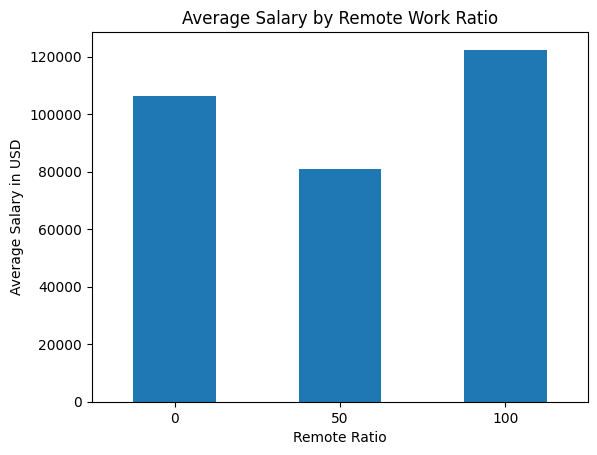

In [13]:
remote_salary = df.groupby("remote_ratio")["salary_in_usd"].mean()

remote_salary.plot(kind="bar")

plt.title("Average Salary by Remote Work Ratio")
plt.xlabel("Remote Ratio")
plt.ylabel("Average Salary in USD")

plt.xticks(rotation=0)

plt.savefig("images/remote_salary.png", bbox_inches="tight")


plt.show()

In [15]:
top_countries = df.groupby("company_location")["salary_in_usd"].mean().sort_values(ascending=False).head(10)

top_countries

company_location
RU    157500.000000
US    144055.261972
NZ    125000.000000
IL    119059.000000
JP    114127.333333
AU    108042.666667
DZ    100000.000000
AE    100000.000000
IQ    100000.000000
CA     99823.733333
Name: salary_in_usd, dtype: float64

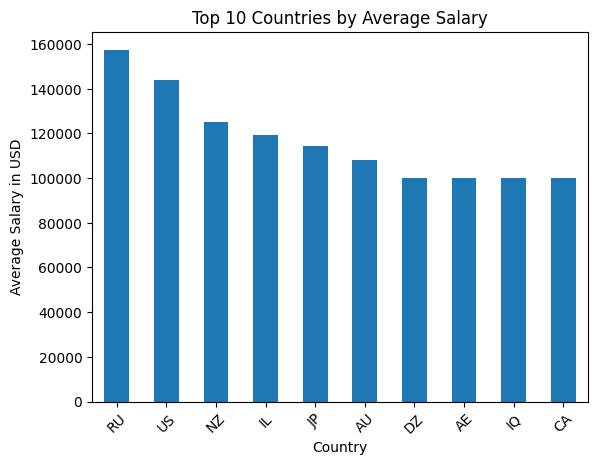

In [14]:
top_countries = df.groupby("company_location")["salary_in_usd"].mean().sort_values(ascending=False).head(10)

top_countries.plot(kind="bar")

plt.title("Top 10 Countries by Average Salary")
plt.xlabel("Country")
plt.ylabel("Average Salary in USD")

plt.xticks(rotation=45)

plt.savefig("images/top_countries.png", bbox_inches="tight")

plt.show()

In [17]:
top_job_count = df["job_title"].value_counts().head(10)

top_job_count

job_title
Data Scientist                143
Data Engineer                 132
Data Analyst                   97
Machine Learning Engineer      41
Research Scientist             16
Data Science Manager           12
Data Architect                 11
Machine Learning Scientist      8
Big Data Engineer               8
Data Science Consultant         7
Name: count, dtype: int64

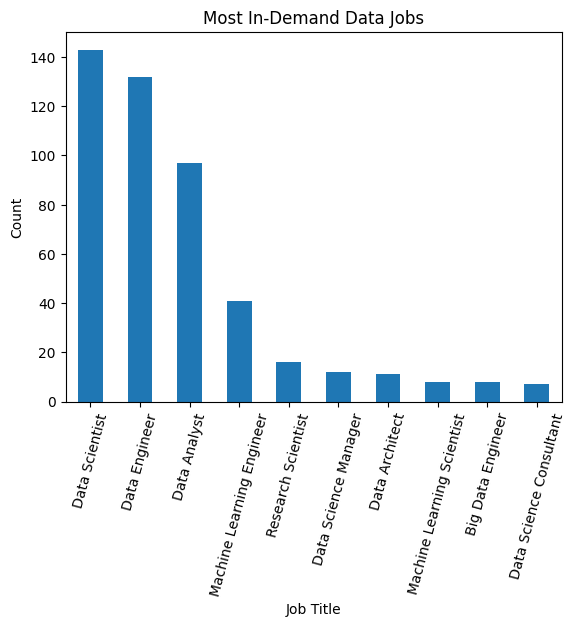

In [15]:
top_job_count = df["job_title"].value_counts().head(10)

top_job_count.plot(kind="bar")

plt.title("Most In-Demand Data Jobs")
plt.xlabel("Job Title")
plt.ylabel("Count")

plt.xticks(rotation=75)

plt.savefig("images/most_demanded_jobs.png", bbox_inches="tight")

plt.show()